In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import joblib
import seaborn as sns
import shutil
import tensorflow as tf
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-02-28 14:21:58.564396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772288518.795229      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772288518.862063      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772288519.389704      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772288519.389765      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772288519.389769      56 computation_placer.cc:177] computation placer alr

/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/yield_scaler.pkl
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/rice_yield_model_final.pkl
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/district_encoder.joblib
/kaggle/input/datasets/sanilawijesekara/inference-coordinates-v1/unique_coordinates.csv
/kaggle/input/datasets/sanilawijesekara/inference-p1/inference_p1.csv


In [4]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


# Dataset loading from pipeline 1

In [5]:
df = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/inference-p1/inference_p1.csv")
df.head()

,pixel_id,year,date,rain_1d_mean,rain_3d_mean,rain_7d_mean,rain_14d_mean,rain_30d_mean,tmean_mean,tmax_mean,...,hazard_flood,hazard_drought,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,stage,district_id,season_id,cycle_id
0,0,2025,2025-10-15,16.600752,55.335840,71.402290,102.589355,112.448006,27.704155,32.227120,...,0,0,0,0,0,0,0,21,0,2025_2026_Maha
1,0,2025,2025-10-30,0.000000,16.152046,100.479580,242.592960,361.783050,26.613668,29.845850,...,0,0,0,0,0,0,0,21,0,2025_2026_Maha
2,0,2025,2025-11-14,0.000000,15.412524,33.223476,42.128952,301.322660,27.029259,30.853373,...,0,0,0,0,0,0,1,21,0,2025_2026_Maha
3,0,2025,2025-11-29,94.259910,162.760160,245.281080,309.123140,351.252100,25.573345,30.247583,...,0,0,0,0,0,0,1,21,0,2025_2026_Maha
4,0,2025,2025-12-14,0.000000,14.107114,14.107114,24.955986,340.732120,25.762974,29.868326,...,0,0,0,0,0,0,3,21,0,2025_2026_Maha


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 61 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   pixel_id              292280 non-null  int64  
 1   year                  292280 non-null  int64  
 2   date                  292280 non-null  object 
 3   rain_1d_mean          292280 non-null  float64
 4   rain_3d_mean          292280 non-null  float64
 5   rain_7d_mean          292280 non-null  float64
 6   rain_14d_mean         292280 non-null  float64
 7   rain_30d_mean         292280 non-null  float64
 8   tmean_mean            292280 non-null  float64
 9   tmax_mean             292280 non-null  float64
 10  tmin_mean             292280 non-null  float64
 11  t_day_mean            292280 non-null  float64
 12  t_night_mean          292280 non-null  float64
 13  rh_mean_mean          292280 non-null  float64
 14  lat                   292280 non-null  float64
 15  

# Feature extraction for LSTM and type conversions

In [7]:
# --- A. Define Dynamic Time-Series Features (X1) ---
ts_features = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 
    'rain_7d_mean', 'rain_14d_mean', 'tmean_mean','bsi_z', 
    'rh_mean_mean', 'delta_days', 'doy_sin', 'doy_cos'
]

# --- B. Define Static Geospatial Features (X2) ---
static_features = ['lat', 'lon', 'elevation', 'slope', 'district_id']

# --- C. Define Multi-Head Targets (Y) ---
# Head 5 is a vector of all hazard columns
hazard_cols = [
    'hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 
    'hazard_landslide', 'hazard_lightning', 'hazard_wind'
]

target_cols = ['stage', 'ndvi_zscore', 'cpi'] + hazard_cols

# 1. Combine all required column names into a single list
# We include pixel_id and date for sequencing later
all_required_cols = (
    ['pixel_id', 'date','year','stage_name','month','season', 'season_id','cycle_id'] + 
    ts_features + 
    static_features + 
    target_cols
)

# 2. Extract only these columns from the main dataframe
# This effectively drops the other ~40 unnecessary columns
df_lstm = df[all_required_cols].copy()

# 3. Optimize Data Types (Crucial for 1.2GB+ datasets)
# Convert Floats to 32-bit to save memory
float_cols = df_lstm.select_dtypes(include=['float64']).columns
df_lstm[float_cols] = df_lstm[float_cols].astype('float32')

# Convert Hazards and Stage to 32-bit Integers
int_cols = ['stage', 'pixel_id', 'district_id'] + hazard_cols
df_lstm[int_cols] = df_lstm[int_cols].astype('int32')

print(f"Extraction complete. New Shape: {df_lstm.shape}")
print(f"Memory Usage Reduced to: {df_lstm.memory_usage().sum() / 1024**2:.2f} MB")

# Optional: Ensure the final extracted df is perfectly typed
df_lstm['stage'] = df_lstm['stage'].astype('int32')
df_lstm['ndvi_zscore'] = df_lstm['ndvi_zscore'].astype('float32')
df_lstm['cpi'] = df_lstm['cpi'].astype('float32')
df_lstm.head()

Extraction complete. New Shape: (292280, 37)
Memory Usage Reduced to: 50.17 MB


,pixel_id,date,year,stage_name,month,season,season_id,cycle_id,ndvi_median_smooth,lswi_median_smooth,...,district_id,stage,ndvi_zscore,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,2025-10-15,2025,Transplant,10,Maha,0,2025_2026_Maha,0.372762,-0.058816,...,21,0,-0.141105,-0.156633,0,0,0,0,0,0
1,0,2025-10-30,2025,Transplant,10,Maha,0,2025_2026_Maha,0.403029,-0.034450,...,21,0,0.137842,-0.514367,0,0,0,0,0,0
2,0,2025-11-14,2025,Vegetative,11,Maha,0,2025_2026_Maha,0.440843,-0.003503,...,21,1,-0.857940,1.657635,0,0,0,0,0,0
3,0,2025-11-29,2025,Vegetative,11,Maha,0,2025_2026_Maha,0.523504,0.030069,...,21,1,-0.211524,1.442566,0,0,0,0,0,0
4,0,2025-12-14,2025,Ripening,12,Maha,0,2025_2026_Maha,0.440592,0.090485,...,21,3,-0.483285,1.279291,0,0,0,0,0,0


In [8]:
df_lstm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pixel_id            292280 non-null  int32  
 1   date                292280 non-null  object 
 2   year                292280 non-null  int64  
 3   stage_name          292280 non-null  object 
 4   month               292280 non-null  int64  
 5   season              292280 non-null  object 
 6   season_id           292280 non-null  int64  
 7   cycle_id            292280 non-null  object 
 8   ndvi_median_smooth  292280 non-null  float32
 9   lswi_median_smooth  292280 non-null  float32
 10  evi_median_smooth   292280 non-null  float32
 11  ndwi_median_smooth  292280 non-null  float32
 12  bsi_median_smooth   292280 non-null  float32
 13  ndvi_vel_z          292280 non-null  float32
 14  lswi_vel_z          292280 non-null  float32
 15  rain_7d_mean        292280 non-nul

# Define feature groups

In [9]:
# --- 1. DEFINE GROUPS ---

# A. Already Scaled (Stage-Aware)
custom_scaled = ['ndvi_vel_z', 'lswi_vel_z', 'bsi_z', 'ndvi_zscore', 'cpi']

# B. Raw Temporal Features (Need Scaling + Go to LSTM)
raw_temporal = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth',
    'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 'rh_mean_mean', 
    'delta_days'
]

# C. Raw Static Features (Need Scaling + Go to Dense Layer)
raw_static = ['elevation', 'slope','lat','lon']

# D. Passthrough (No Scaling)
passthrough = ['doy_sin', 'doy_cos']

# --- 2. DEFINE INPUT LISTS (The Fix) ---

# LSTM Inputs (Only Time-Series)
TS_FEATURES = custom_scaled + raw_temporal + passthrough 
# This list now correctly EXCLUDES lat/lon/elevation/slope

# Scaling List (Both Temporal and Static)
features_to_scale = raw_temporal + raw_static

# Scaling

In [10]:
scaler = joblib.load("/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib")
df_lstm[features_to_scale] = scaler.transform(df_lstm[features_to_scale])

In [11]:
df_lstm.head()

,pixel_id,date,year,stage_name,month,season,season_id,cycle_id,ndvi_median_smooth,lswi_median_smooth,...,district_id,stage,ndvi_zscore,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,2025-10-15,2025,Transplant,10,Maha,0,2025_2026_Maha,-0.857947,-1.031677,...,21,0,-0.141105,-0.156633,0,0,0,0,0,0
1,0,2025-10-30,2025,Transplant,10,Maha,0,2025_2026_Maha,-0.667449,-0.868776,...,21,0,0.137842,-0.514367,0,0,0,0,0,0
2,0,2025-11-14,2025,Vegetative,11,Maha,0,2025_2026_Maha,-0.429452,-0.661881,...,21,1,-0.857940,1.657635,0,0,0,0,0,0
3,0,2025-11-29,2025,Vegetative,11,Maha,0,2025_2026_Maha,0.090810,-0.437434,...,21,1,-0.211524,1.442566,0,0,0,0,0,0
4,0,2025-12-14,2025,Ripening,12,Maha,0,2025_2026_Maha,-0.431033,-0.033515,...,21,3,-0.483285,1.279291,0,0,0,0,0,0


In [12]:
df_lstm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pixel_id            292280 non-null  int32  
 1   date                292280 non-null  object 
 2   year                292280 non-null  int64  
 3   stage_name          292280 non-null  object 
 4   month               292280 non-null  int64  
 5   season              292280 non-null  object 
 6   season_id           292280 non-null  int64  
 7   cycle_id            292280 non-null  object 
 8   ndvi_median_smooth  292280 non-null  float64
 9   lswi_median_smooth  292280 non-null  float64
 10  evi_median_smooth   292280 non-null  float64
 11  ndwi_median_smooth  292280 non-null  float64
 12  bsi_median_smooth   292280 non-null  float64
 13  ndvi_vel_z          292280 non-null  float32
 14  lswi_vel_z          292280 non-null  float32
 15  rain_7d_mean        292280 non-nul

In [13]:
df = df_lstm

# Adding flood index, ndvi_delta, is_growing and clipping

In [14]:
def prepare_inference_physics(df):
    """Adds the specific physics features used in RiceVision V7"""
    # 1. Physics: High Flood Index = Water; Low = Soil
    df['flood_index'] = df['lswi_median_smooth'] - df['ndvi_median_smooth']
    
    # 2. Physics: Change in NDVI (Velocity)
    df['ndvi_delta'] = df.groupby('pixel_id')['ndvi_median_smooth'].diff().fillna(0)
    
    # 3. Gating Feature: 1 if growing (Stages 1,2,3), 0 if off-season (0,4)
    # This must be derived from the 'stage' column we inferred earlier
    df['is_growing'] = df['stage'].isin([1, 2, 3]).astype('float32')
    
    # 4. Clipping: Match the training distribution
    df['ndvi_zscore'] = df['ndvi_zscore'].clip(-4.0, 4.0)
    if 'cpi' in df.columns:
        df['cpi'] = df['cpi'].clip(-4.0, 4.0)
        
    return df
df = prepare_inference_physics(df)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 40 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pixel_id            292280 non-null  int32  
 1   date                292280 non-null  object 
 2   year                292280 non-null  int64  
 3   stage_name          292280 non-null  object 
 4   month               292280 non-null  int64  
 5   season              292280 non-null  object 
 6   season_id           292280 non-null  int64  
 7   cycle_id            292280 non-null  object 
 8   ndvi_median_smooth  292280 non-null  float64
 9   lswi_median_smooth  292280 non-null  float64
 10  evi_median_smooth   292280 non-null  float64
 11  ndwi_median_smooth  292280 non-null  float64
 12  bsi_median_smooth   292280 non-null  float64
 13  ndvi_vel_z          292280 non-null  float32
 14  lswi_vel_z          292280 non-null  float32
 15  rain_7d_mean        292280 non-nul

<Axes: xlabel='cpi', ylabel='Density'>

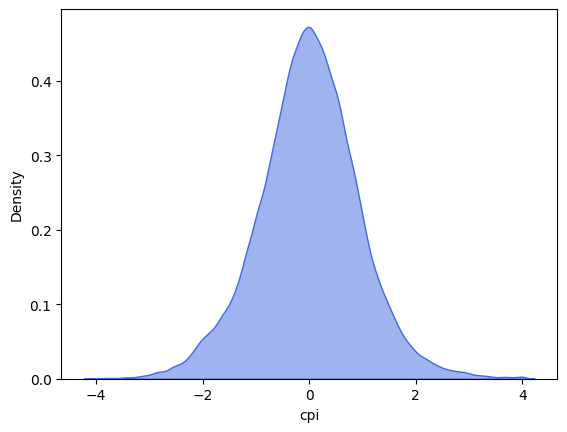

In [16]:
sns.kdeplot(df['cpi'], fill=True, color='royalblue', alpha=0.5)

<Axes: xlabel='ndvi_zscore', ylabel='Density'>

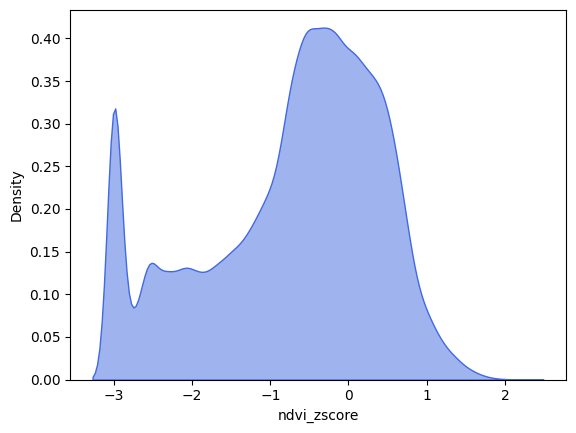

In [17]:
sns.kdeplot(df['ndvi_zscore'], fill=True, color='royalblue', alpha=0.5)

In [18]:
df.to_csv("Inference_preprocessed.csv", index=False)
print("dataset saved successfully")

dataset saved successfully


# Temporal Sequencing and categorizing inputs for lstm

In [19]:
def create_inference_sequences(df, window_size=10):
    """
    Groups data by pixel and creates windows of size 10.
    Pixels with fewer than 10 observations are skipped for that specific window.
    """
    # Feature Lists (MUST match your training order exactly)
    base_ts_features = [
        'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
        'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 
        'bsi_z', 'ndvi_zscore', 'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 
        'rh_mean_mean', 'delta_days', 'doy_sin', 'doy_cos', 'is_growing'
    ]
    hazard_cols = [
        'hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 
        'hazard_landslide', 'hazard_lightning', 'hazard_wind'
    ]
    ts_features = base_ts_features + hazard_cols + ['flood_index', 'ndvi_delta']
    static_features = ['lat', 'lon', 'elevation', 'slope', 'season_id', 'doy_sin', 'doy_cos']

    # Sort temporally per pixel
    df = df.sort_values(['pixel_id', 'date']).reset_index(drop=True)
    
    # Generate Group IDs
    df['group_id'] = df.groupby('pixel_id').ngroup()
    
    # Arrays for processing
    ts_data = df[ts_features].values.astype('float32')
    static_data = df[static_features].values.astype('float32')
    dist_data = df['district_id'].values.astype('int32')
    group_ids = df['group_id'].values

    total_rows = len(df)
    starts = np.arange(total_rows - window_size + 1)
    ends = starts + window_size - 1
    
    # Ensure window doesn't cross between different pixels
    valid_mask = (group_ids[starts] == group_ids[ends])
    valid_starts = starts[valid_mask]
    indices_2d = valid_starts[:, None] + np.arange(window_size)[None, :]
    valid_ends = valid_starts + window_size - 1

    X = {
        "temporal_input": ts_data[indices_2d],
        "static_input": static_data[valid_ends],
        "district_input": dist_data[valid_ends]
    }
    
    # Keep track of which pixel/date each prediction belongs to
    meta = df.iloc[valid_ends][['pixel_id', 'date', 'district_id', 'is_growing']].copy()
    
    return X, meta

# Inference execution

In [20]:
le = joblib.load("/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/district_encoder.joblib")

In [21]:
def weighted_stage_ce_v2(y_true, y_pred):
    """
    Revised weights to reduce "Transplant" false positives.
    Instead of 8.0, we use 3.0 to balance importance with reality.
    Weights: [0: Transplant, 1: Vegetative, 2: Reproductive, 3: Ripening, 4: Harvest]
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    # 4.0 for Reproductive (critical for yield) and 3.0 for Transplant
    class_weights = tf.constant([3.0, 1.5, 4.0, 1.5, 1.0], dtype=tf.float32)
    weights = tf.gather(class_weights, y_true)
    
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(loss * weights)

def robust_huber_loss(y_true, y_pred):
    """Robust to NDVI outliers, smooth gradients for precise Z-scores."""
    return tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

# --- 2. CUSTOM METRICS ---

def regression_accuracy(y_true, y_pred):
    """Calculates % of predictions within 0.5 of the actual value."""
    diff = tf.abs(tf.squeeze(y_true) - tf.squeeze(y_pred))
    return tf.reduce_mean(tf.cast(diff < 0.5, tf.float32))
    
def run_model_inference(df, model_path="/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras"):
    
    # 2. Generate Sequences
    X_inf, meta = create_inference_sequences(df, window_size=10)
    
    # 3. Load Model
    # Note: We pass the custom loss functions so Keras knows how to read the file
    model = tf.keras.models.load_model(model_path, custom_objects={
        'weighted_stage_ce_v2': weighted_stage_ce_v2,
        'robust_huber_loss': robust_huber_loss,
        'regression_accuracy': regression_accuracy  # Don't forget this!
    })
    
    # 4. Predict
    print(f"🚀 Running inference on {len(meta)} sequences...")
    preds = model.predict([X_inf["temporal_input"], X_inf["static_input"], X_inf["district_input"]])
    
    # preds[0] = stage (Softmax), preds[1] = health (Z-score), preds[2] = pest (CPI)
    
    # 5. Decode Predictions
    meta['pred_stage_id'] = np.argmax(preds[0], axis=1)
    meta['pred_health_z'] = preds[1].flatten()
    meta['pred_pest_cpi'] = preds[2].flatten()
    
    # 6. Apply Gating (Masking)
    # If the pixel is not in a growing stage, we zero out the health/pest impacts
    meta['final_health_impact'] = meta['pred_health_z'] * meta['is_growing']
    meta['final_pest_impact'] = meta['pred_pest_cpi'] * meta['is_growing']
    
    # Map stage ID back to name
    stage_rev_map = {0: 'Transplant', 1: 'Vegetative', 2: 'Reproductive', 3: 'Ripening', 4: 'Harvest'}
    meta['pred_stage_name'] = meta['pred_stage_id'].map(stage_rev_map)
    
    # --- OPTIONAL: GET DISTRICT NAMES BACK ---
    # If you still have your LabelEncoder 'le', you can recover names:
    meta['district'] = le.inverse_transform(meta['district_id'])
    
    print("✅ Inference Complete.")
    return meta

# --- FINAL EXECUTION ---
results_df = run_model_inference(df)
print(results_df[['pixel_id', 'date', 'pred_stage_name', 'final_health_impact','final_pest_impact']].head())

2026-02-28 14:22:43.627932: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


🚀 Running inference on 29228 sequences...
914/914 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step
✅ Inference Complete.
    pixel_id        date pred_stage_name  final_health_impact  \
9          0  2026-02-27      Transplant                 -0.0   
19         1  2026-02-27      Transplant                 -0.0   
29         2  2026-02-27      Transplant                 -0.0   
39         3  2026-02-27      Transplant                 -0.0   
49         4  2026-02-27      Transplant                 -0.0   

    final_pest_impact  
9                -0.0  
19                0.0  
29               -0.0  
39                0.0  
49               -0.0  


In [22]:
results_df.head()

,pixel_id,date,district_id,is_growing,pred_stage_id,pred_health_z,pred_pest_cpi,final_health_impact,final_pest_impact,pred_stage_name,district
9,0,2026-02-27,21,0.0,0,-2.004113,-0.194262,-0.0,-0.0,Transplant,Puttalam
19,1,2026-02-27,21,0.0,0,-2.857412,0.113021,-0.0,0.0,Transplant,Puttalam
29,2,2026-02-27,21,0.0,0,-2.327225,-0.029662,-0.0,-0.0,Transplant,Puttalam
39,3,2026-02-27,21,0.0,0,-2.869345,0.258171,-0.0,0.0,Transplant,Puttalam
49,4,2026-02-27,21,0.0,0,-2.801023,-0.035784,-0.0,-0.0,Transplant,Puttalam


In [23]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29228 entries, 9 to 292279
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pixel_id             29228 non-null  int32  
 1   date                 29228 non-null  object 
 2   district_id          29228 non-null  int32  
 3   is_growing           29228 non-null  float32
 4   pred_stage_id        29228 non-null  int64  
 5   pred_health_z        29228 non-null  float32
 6   pred_pest_cpi        29228 non-null  float32
 7   final_health_impact  29228 non-null  float32
 8   final_pest_impact    29228 non-null  float32
 9   pred_stage_name      29228 non-null  object 
 10  district             29228 non-null  object 
dtypes: float32(5), int32(2), int64(1), object(3)
memory usage: 1.9+ MB


# Evaluating predictions

<Axes: >

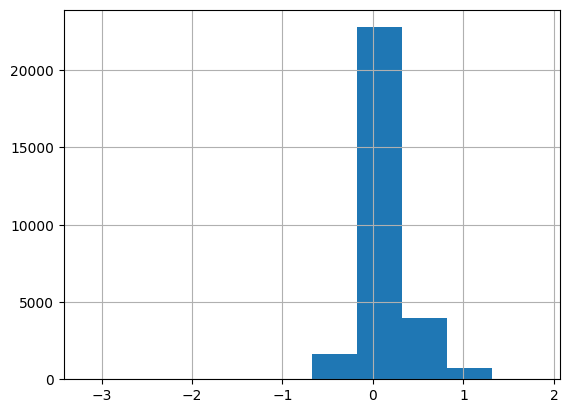

In [24]:
results_df['final_health_impact'].hist()

<Axes: >

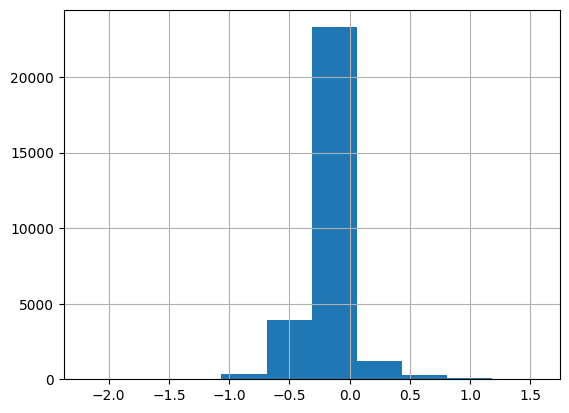

In [25]:
results_df['final_pest_impact'].hist()

In [26]:
results_df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pixel_id,29228.0,NaN,NaN,NaN,14613.694437,8437.812473,0.0,7306.75,14613.5,21920.25,29228.0
date,29228,1,2026-02-27,29228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_id,29228.0,NaN,NaN,NaN,10.585295,8.434911,0.0,1.0,12.0,20.0,24.0
is_growing,29228.0,NaN,NaN,NaN,0.385213,0.486662,0.0,0.0,0.0,1.0,1.0
pred_stage_id,29228.0,NaN,NaN,NaN,1.948987,1.555301,0.0,0.0,2.0,4.0,4.0
pred_health_z,29228.0,NaN,NaN,NaN,-0.683338,1.216461,-3.288839,-1.94458,-0.17,0.282672,1.813516
pred_pest_cpi,29228.0,NaN,NaN,NaN,-0.173015,0.351949,-2.225038,-0.395746,-0.205212,0.019455,2.441673
final_health_impact,29228.0,NaN,NaN,NaN,0.092877,0.266344,-3.169744,0.0,-0.0,0.071125,1.813516
final_pest_impact,29228.0,NaN,NaN,NaN,-0.085662,0.216299,-2.186486,-0.154282,-0.0,0.0,1.554489
pred_stage_name,29228,5,Reproductive,10602,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

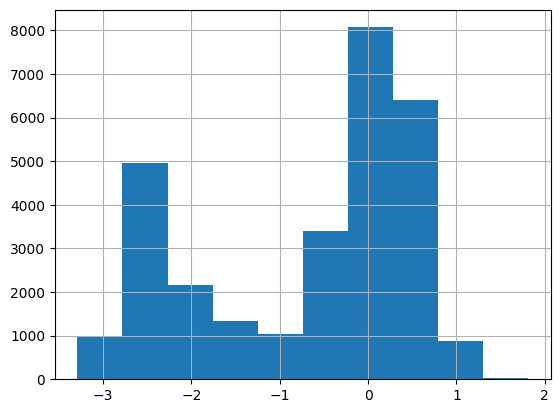

In [27]:
results_df['pred_health_z'].hist()

<Axes: >

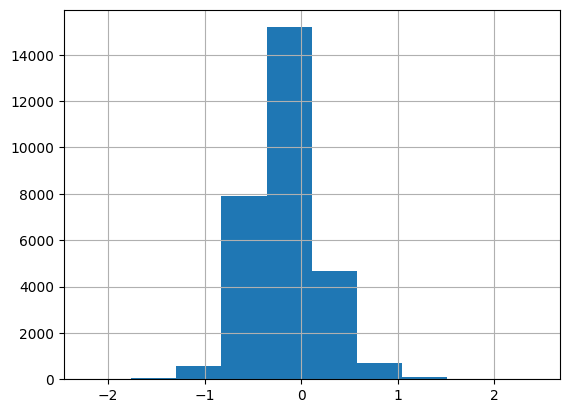

In [28]:
results_df['pred_pest_cpi'].hist()

<Axes: >

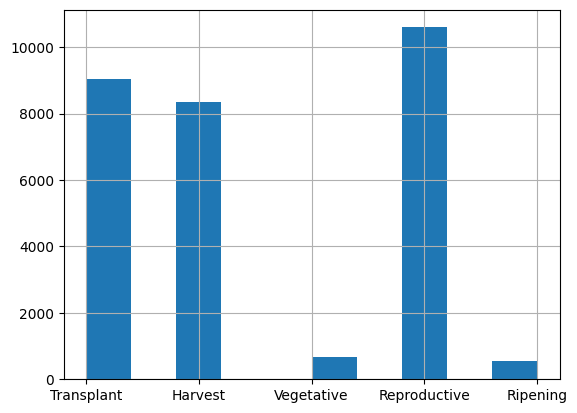

In [29]:
results_df['pred_stage_name'].hist()

# Categorizing inference results

In [30]:
def categorize_inference_results(meta_df):
    print("🏷️ Categorizing Health and Pest anomalies...")
    
    # --- 1. HEALTH CATEGORIZATION (NDVI Z-Score) ---
    def get_health_label(row):
        # Stage-Gating: No health alerts for Transplant/Harvest
        if row['pred_stage_name'] in ['Transplant', 'Harvest']:
            return 'Not Applicable'
        
        z = row['pred_health_z']
        
        if z > 1.0: return 'Healthy'
        elif -1.0 <= z <= 1.0: return 'Normal'
        elif -2.0 <= z < -1.0: return 'Mild Stress'
        else: return 'Severe Stress'

    meta_df['health_category'] = meta_df.apply(get_health_label, axis=1)

    # --- 2. PEST ATTACK DETECTION (CPI) ---
    # Since we are in inference, we calculate stats on the current prediction batch
    # to find the "Local Anomalies" (The top 5% worst pixels)
    
    # Calculate thresholds per stage from the predictions
    pest_stats = meta_df.groupby('pred_stage_name')['pred_pest_cpi'].agg(['median', 'std', lambda x: x.quantile(0.95)]).reset_index()
    pest_stats.columns = ['pred_stage_name', 'cpi_med', 'cpi_std', 'cpi_q95']
    
    # Merge thresholds back
    meta_df = meta_df.merge(pest_stats, on='pred_stage_name', how='left')

    def detect_pest_flag(row):
        # 1. Stage Check: Ignore non-growing periods
        if row['pred_stage_name'] in ['Transplant', 'Harvest']:
            return 0
        
        # 2. Hybrid Logic:
        # A. Local: Is it in the worst 5% of the current batch?
        is_local_anomaly = row['pred_pest_cpi'] >= row['cpi_q95']
        
        # B. Global: Is it significantly worse than the average? (1.5 Sigma)
        is_global_anomaly = row['pred_pest_cpi'] > (row['cpi_med'] + (1.5 * row['cpi_std']))
        
        return 1 if (is_local_anomaly and is_global_anomaly) else 0

    meta_df['pest_flag'] = meta_df.apply(detect_pest_flag, axis=1)
    
    # Cleanup helper columns
    meta_df = meta_df.drop(columns=['cpi_med', 'cpi_std', 'cpi_q95'])
    
    return meta_df

# --- EXECUTE ---
results_df = categorize_inference_results(results_df)

# Show a summary of the findings
print(results_df['health_category'].value_counts())
print(f"🚨 Total Pest Attacks Detected: {results_df['pest_flag'].sum()}")

🏷️ Categorizing Health and Pest anomalies...
health_category
Not Applicable    17383
Normal            11256
Severe Stress       221
Healthy             219
Mild Stress         149
Name: count, dtype: int64
🚨 Total Pest Attacks Detected: 595


In [31]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pixel_id             29228 non-null  int32  
 1   date                 29228 non-null  object 
 2   district_id          29228 non-null  int32  
 3   is_growing           29228 non-null  float32
 4   pred_stage_id        29228 non-null  int64  
 5   pred_health_z        29228 non-null  float32
 6   pred_pest_cpi        29228 non-null  float32
 7   final_health_impact  29228 non-null  float32
 8   final_pest_impact    29228 non-null  float32
 9   pred_stage_name      29228 non-null  object 
 10  district             29228 non-null  object 
 11  health_category      29228 non-null  object 
 12  pest_flag            29228 non-null  int64  
dtypes: float32(5), int32(2), int64(2), object(4)
memory usage: 2.1+ MB


In [32]:
results_df.head()

,pixel_id,date,district_id,is_growing,pred_stage_id,pred_health_z,pred_pest_cpi,final_health_impact,final_pest_impact,pred_stage_name,district,health_category,pest_flag
0,0,2026-02-27,21,0.0,0,-2.004113,-0.194262,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0
1,1,2026-02-27,21,0.0,0,-2.857412,0.113021,-0.0,0.0,Transplant,Puttalam,Not Applicable,0
2,2,2026-02-27,21,0.0,0,-2.327225,-0.029662,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0
3,3,2026-02-27,21,0.0,0,-2.869345,0.258171,-0.0,0.0,Transplant,Puttalam,Not Applicable,0
4,4,2026-02-27,21,0.0,0,-2.801023,-0.035784,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0


<Axes: >

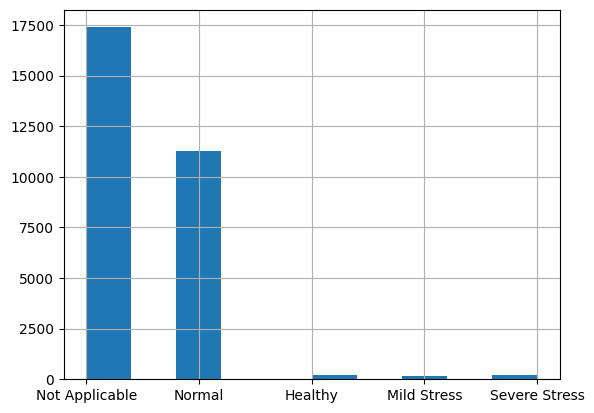

In [33]:
results_df['health_category'].hist()

<Axes: >

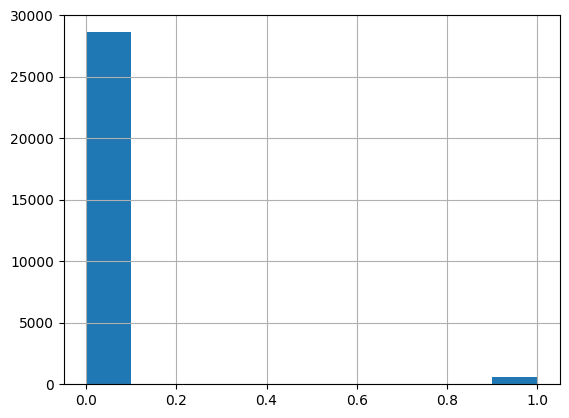

In [34]:
results_df['pest_flag'].hist()

# Merging lan lat columns

In [35]:
df_coord = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/inference-coordinates-v1/unique_coordinates.csv")
df_coord.head()

,pixel_id,lat,lon
0,0,7.961319,79.750184
1,22001,8.051152,81.250373
2,6024,9.344724,80.302649
3,22000,8.055643,81.250373
4,21999,8.019711,81.250373


In [36]:
# --- 2. MERGE INTO RESULTS ---
print("🔗 Merging coordinates into results_df...")

# We use a 'left' merge to ensure we don't lose any prediction rows
# This matches the 'lat' and 'lon' to every occurrence of 'pixel_id' in your results
results_df = results_df.merge(df_coord, on='pixel_id', how='left')

🔗 Merging coordinates into results_df...


In [37]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pixel_id             29228 non-null  int32  
 1   date                 29228 non-null  object 
 2   district_id          29228 non-null  int32  
 3   is_growing           29228 non-null  float32
 4   pred_stage_id        29228 non-null  int64  
 5   pred_health_z        29228 non-null  float32
 6   pred_pest_cpi        29228 non-null  float32
 7   final_health_impact  29228 non-null  float32
 8   final_pest_impact    29228 non-null  float32
 9   pred_stage_name      29228 non-null  object 
 10  district             29228 non-null  object 
 11  health_category      29228 non-null  object 
 12  pest_flag            29228 non-null  int64  
 13  lat                  29228 non-null  float64
 14  lon                  29228 non-null  float64
dtypes: float32(5), float64(2), int32(2),

In [38]:
results_df.head()

,pixel_id,date,district_id,is_growing,pred_stage_id,pred_health_z,pred_pest_cpi,final_health_impact,final_pest_impact,pred_stage_name,district,health_category,pest_flag,lat,lon
0,0,2026-02-27,21,0.0,0,-2.004113,-0.194262,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0,7.961319,79.750184
1,1,2026-02-27,21,0.0,0,-2.857412,0.113021,-0.0,0.0,Transplant,Puttalam,Not Applicable,0,7.947844,79.750184
2,2,2026-02-27,21,0.0,0,-2.327225,-0.029662,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0,7.956829,79.750184
3,3,2026-02-27,21,0.0,0,-2.869345,0.258171,-0.0,0.0,Transplant,Puttalam,Not Applicable,0,7.952334,79.750184
4,4,2026-02-27,21,0.0,0,-2.801023,-0.035784,-0.0,-0.0,Transplant,Puttalam,Not Applicable,0,7.934368,79.750184


# Visualizing across sri lanka

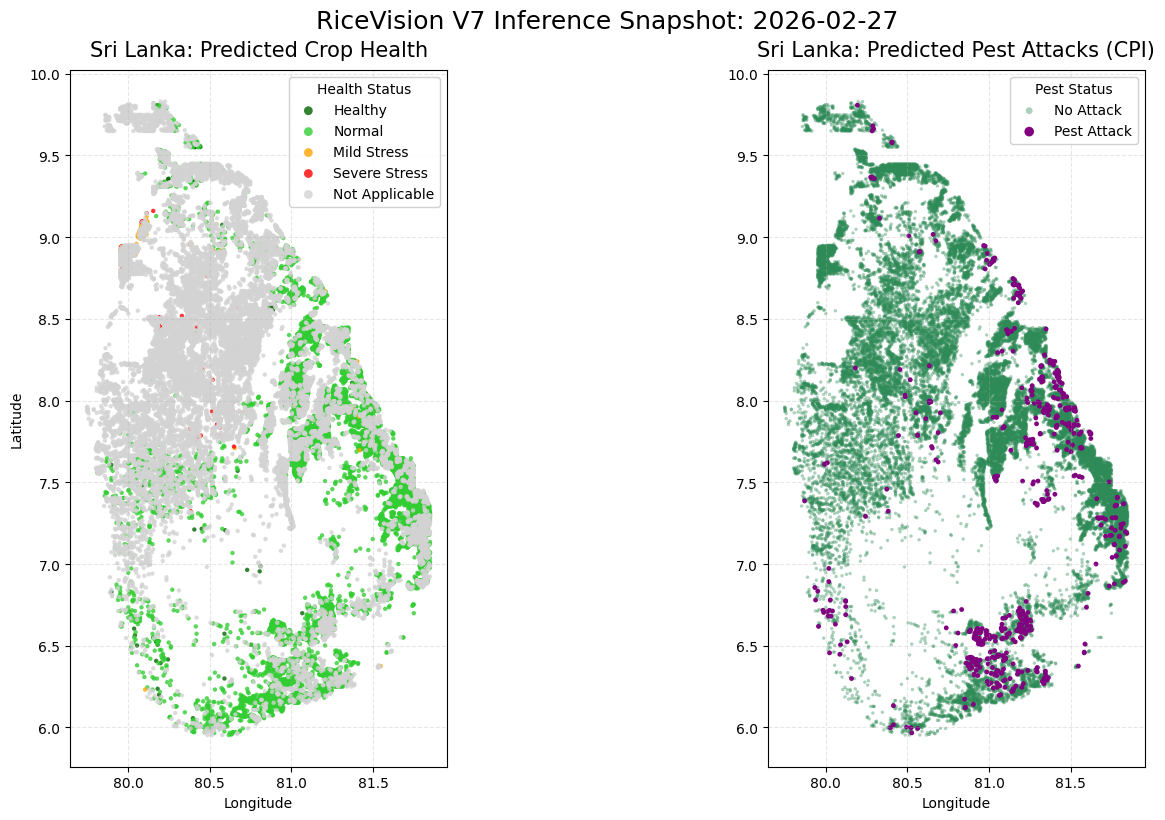

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure date is datetime to allow proper sorting and title formatting
results_df['date'] = pd.to_datetime(results_df['date'])

# 2. Filter for the latest state per pixel
# This ensures each of the 4719 points is represented by its most recent prediction
latest_status = results_df.sort_values('date').groupby('pixel_id').tail(1)

# 3. Set up the overall figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- PLOT 1: CROP HEALTH CATEGORIES ---
health_colors = {
    'Healthy': '#006400',       # Dark Green
    'Normal': '#32CD32',        # Lime Green
    'Mild Stress': '#FFA500',   # Orange
    'Severe Stress': '#FF0000', # Red
    'Not Applicable': '#D3D3D3' # Light Gray (Off-season)
}

for category, color in health_colors.items():
    subset = latest_status[latest_status['health_category'] == category]
    if not subset.empty:
        ax1.scatter(
            subset['lon'], 
            subset['lat'], 
            c=color, 
            label=category, 
            s=10, 
            alpha=0.8,
            edgecolors='none'
        )

ax1.set_title('Sri Lanka: Predicted Crop Health', fontsize=15, pad=10)

# LEGEND MOVED TO UPPER RIGHT
ax1.legend(
    title="Health Status", 
    loc='upper right', 
    markerscale=2, 
    frameon=True, 
    framealpha=0.9
)

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_aspect('equal')

# --- PLOT 2: PEST ATTACK FLAGS ---
pest_colors = {
    0: ('#2E8B57', 'No Attack', 0.4), # SeaGreen (Faded)
    1: ('#800080', 'Pest Attack', 1.0) # Purple (Bold)
}

for flag, (color, label, alpha) in pest_colors.items():
    subset = latest_status[latest_status['pest_flag'] == flag]
    if not subset.empty:
        ax2.scatter(
            subset['lon'], 
            subset['lat'], 
            c=color, 
            label=label, 
            s=12 if flag == 1 else 6, # Make attacks slightly larger
            alpha=alpha,
            edgecolors='none'
        )

ax2.set_title('Sri Lanka: Predicted Pest Attacks (CPI)', fontsize=15, pad=10)

# LEGEND MOVED TO UPPER RIGHT
ax2.legend(
    title="Pest Status", 
    loc='upper right', 
    markerscale=2, 
    frameon=True, 
    framealpha=0.9
)

ax2.set_xlabel('Longitude')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_aspect('equal')

# 4. Final layout adjustments
plt.tight_layout()

# Formatting the timestamp for the title
current_date_str = latest_status['date'].max().strftime('%Y-%m-%d')
plt.suptitle(f"RiceVision V7 Inference Snapshot: {current_date_str}", 
             fontsize=18, y=1.02)

plt.show()

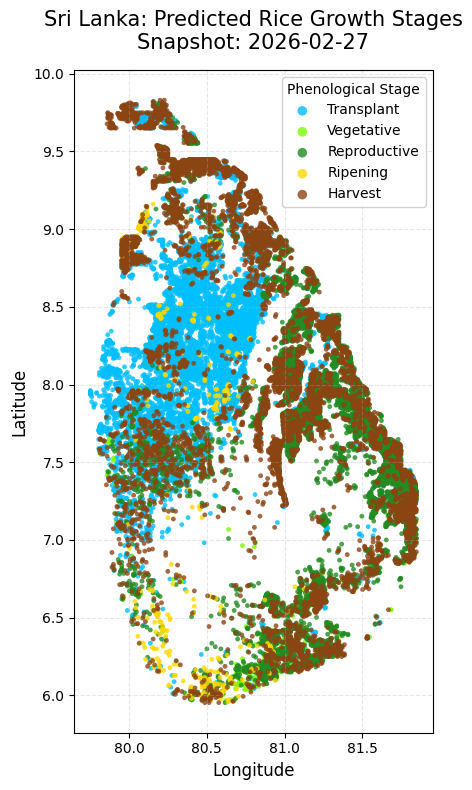

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure date is datetime to allow proper sorting and title formatting
results_df['date'] = pd.to_datetime(results_df['date'])

# 2. Filter for the latest state per pixel
# This ensures each of the 4719 points is represented by its most recent prediction
latest_status = results_df.sort_values('date').groupby('pixel_id').tail(1)

# 3. Set up the figure
plt.figure(figsize=(8, 8))

# --- PLOT: RICE GROWTH STAGES ---
# Defined in chronological order of the rice life cycle
stage_colors = {
    'Transplant': '#00BFFF',    # Deep Sky Blue (Water-heavy stage)
    'Vegetative': '#7CFC00',     # Lawn Green (Initial leaf growth)
    'Reproductive': '#228B22',   # Forest Green (Peak biomass)
    'Ripening': '#FFD700',       # Gold (Grains turning yellow)
    'Harvest': '#8B4513'         # Saddle Brown (Dried plant/Soil)
}

# Ensure we plot in chronological order so the legend looks organized
ordered_stages = ['Transplant', 'Vegetative', 'Reproductive', 'Ripening', 'Harvest']

for stage in ordered_stages:
    if stage in stage_colors:
        color = stage_colors[stage]
        subset = latest_status[latest_status['pred_stage_name'] == stage]
        
        if not subset.empty:
            plt.scatter(
                subset['lon'], 
                subset['lat'], 
                c=color, 
                label=stage, 
                s=12, 
                alpha=0.8,
                edgecolors='none'
            )

# 4. Add labels and styling
current_date_str = latest_status['date'].max().strftime('%Y-%m-%d')
plt.title(f'Sri Lanka: Predicted Rice Growth Stages\nSnapshot: {current_date_str}', fontsize=15, pad=15)

# LEGEND MOVED TO UPPER RIGHT
plt.legend(
    title="Phenological Stage", 
    loc='upper right', 
    markerscale=2, 
    frameon=True, 
    framealpha=0.9,
    fontsize=10
)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Ensure the map isn't distorted
plt.gca().set_aspect('equal', adjustable='box')

# 5. Show the plot
plt.tight_layout()
plt.show()

# Generating reports

In [41]:
import pandas as pd
import numpy as np

def generate_ricevision_report(df):
    print("📊 Generating Comprehensive RiceVision Report...")
    
    # Ensure date is datetime
    df['date'] = pd.to_datetime(df['date'])
    latest_date = df['date'].max()
    
    # --- 1. DISTRICT-LEVEL RISK ANALYSIS (CURRENT SNAPSHOT) ---
    # We look at the most recent data for every pixel
    latest_df = df[df['date'] == latest_date]
    
    district_report = latest_df.groupby('district').agg(
        total_pixels=('pixel_id', 'count'),
        severe_stress_pct=('health_category', lambda x: (x == 'Severe Stress').mean() * 100),
        pest_attack_count=('pest_flag', 'sum'),
        most_common_stage=('pred_stage_name', lambda x: x.value_counts().index[0])
    ).reset_index()
    
    # Calculate a Risk Score (0-100)
    district_report['risk_score'] = (district_report['severe_stress_pct'] * 0.7) + \
                                   (district_report['pest_attack_count'] / district_report['total_pixels'] * 30)
    
    district_report = district_report.sort_values('risk_score', ascending=False)

    # --- 2. TEMPORAL TRENDS (PAST TO PRESENT) ---
    # Calculate national health average over time
    trend_report = df.groupby('date').agg(
        avg_z_score=('pred_health_z', 'mean'),
        pest_incidence=('pest_flag', 'mean')
    ).reset_index()

    # --- 3. HARVEST FORECASTING (THE FUTURE) ---
    # Estimate days to harvest based on current stage
    # Average rice cycle remaining days: Reproductive (~60), Ripening (~20)
    days_to_harvest = {
        'Transplant': 100,
        'Vegetative': 70,
        'Reproductive': 40,
        'Ripening': 15,
        'Harvest': 0
    }
    
    latest_df['est_harvest_date'] = latest_df['pred_stage_name'].map(days_to_harvest)
    latest_df['est_harvest_date'] = pd.to_timedelta(latest_df['est_harvest_date'], unit='D') + latest_df['date']
    
    forecast_report = latest_df.groupby('district')['est_harvest_date'].median().reset_index()

    # --- PRINTING THE REPORT ---
    print(f"\n{'='*60}")
    print(f"🌾 RICEVISION V7 EXECUTIVE REPORT | {latest_date.date()}")
    print(f"{'='*60}")
    
    print("\n🚨 TOP 5 DISTRICTS BY RISK LEVEL:")
    print(district_report[['district', 'risk_score', 'severe_stress_pct', 'most_common_stage']].head(5).to_string(index=False))
    
    print("\n📈 NATIONAL HEALTH TREND (Last 3 Timesteps):")
    print(trend_report.tail(3).to_string(index=False))
    
    print("\n📅 UPCOMING HARVEST FORECAST (Median Date per District):")
    print(forecast_report.sort_values('est_harvest_date').head(5).to_string(index=False))
    
    return district_report, trend_report, forecast_report

# Run the report
dist_rep, trend_rep, fore_rep = generate_ricevision_report(results_df)

📊 Generating Comprehensive RiceVision Report...

🌾 RICEVISION V7 EXECUTIVE REPORT | 2026-02-27

🚨 TOP 5 DISTRICTS BY RISK LEVEL:
  district  risk_score  severe_stress_pct most_common_stage
    Mannar    7.286245          10.408922           Harvest
Monaragala    3.600917           0.000000      Reproductive
 Kaluthara    3.356643           0.000000      Reproductive
   Colombo    3.272727           0.000000           Harvest
   Kegalle    2.031250           1.562500        Transplant

📈 NATIONAL HEALTH TREND (Last 3 Timesteps):
      date  avg_z_score  pest_incidence
2026-02-27    -0.683338        0.020357

📅 UPCOMING HARVEST FORECAST (Median Date per District):
    district est_harvest_date
 Kilinochchi       2026-02-27
Nuwara Eliya       2026-02-27
  Mullaitivu       2026-02-27
      Jaffna       2026-02-27
       Kandy       2026-02-27


In [42]:
dist_rep

,district,total_pixels,severe_stress_pct,pest_attack_count,most_common_stage,risk_score
14,Mannar,1076,10.408922,0,Harvest,7.286245
17,Monaragala,1308,0.000000,157,Reproductive,3.600917
9,Kaluthara,143,0.000000,16,Reproductive,3.356643
4,Colombo,55,0.000000,6,Harvest,3.272727
11,Kegalle,64,1.562500,2,Transplant,2.031250
3,Batticaloa,3234,0.030921,150,Reproductive,1.413111
1,Anuradhapura,4720,1.779661,14,Transplant,1.334746
7,Hambantota,1407,0.000000,60,Reproductive,1.279318
15,Matale,539,0.927644,8,Harvest,1.094620
16,Matara,273,0.000000,7,Ripening,0.769231


In [43]:
trend_rep

,date,avg_z_score,pest_incidence
0,2026-02-27,-0.683338,0.020357


In [44]:
fore_rep

,district,est_harvest_date
0,Ampara,2026-04-08
1,Anuradhapura,2026-06-07
2,Badulla,2026-03-14
3,Batticaloa,2026-04-08
4,Colombo,2026-04-08
5,Galle,2026-03-14
6,Gampaha,2026-06-07
7,Hambantota,2026-04-08
8,Jaffna,2026-02-27
9,Kaluthara,2026-04-08


# Saving reports

In [45]:
results_df.to_csv("lstm_inference_resuls.csv", index = False)
dist_rep.to_csv("district_report.csv", index=False)
trend_rep.to_csv("trend_report.csv", index=False)
fore_rep.to_csv("forecast_report.csv", index=False)